# Question 3: Object Detection using YOLOv8

## Aim
To perform object detection using the YOLOv8 model on the COCO128 dataset.

## Objective
- Load the COCO128 dataset.
- Load the pre-trained YOLOv8 model.
- Train the model.
- Perform object detection on test images.
- Display detected objects with bounding boxes.
- Evaluate the model using Precision, Recall and mAP.

## Dataset
- **Dataset:** COCO128
- **Model:** YOLOv8n
- **Image Size:** 640×640

## Libraries Used
- Ultralytics YOLO
- OpenCV
- Matplotlib

## Expected Outcome
The model should detect multiple objects with bounding boxes, confidence scores and class labels.

✅ Image downloaded successfully!

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 159.0ms
Speed: 4.4ms preprocess, 159.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-5

✅ Prediction Completed!

Detected Objects:

bus : 0.87
person : 0.87
person : 0.85
person : 0.83
person : 0.26
stop sign : 0.26


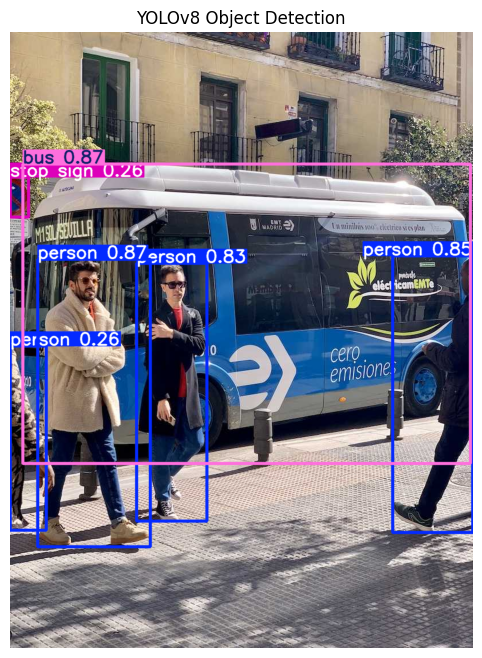

In [6]:
# ============================================================
# YOLOv8 Object Detection on an Online Image (Google Colab)
# ============================================================

# Install Ultralytics (Run only once)
!pip install -q ultralytics

# ============================================================
# Import Libraries
# ============================================================
from ultralytics import YOLO
import requests
import matplotlib.pyplot as plt

# ============================================================
# Load YOLOv8 Pre-trained Model
# ============================================================
model = YOLO("yolov8n.pt")

# ============================================================
# Download Image from Internet
# ============================================================
url = "https://ultralytics.com/images/bus.jpg"

image_name = "bus.jpg"

response = requests.get(url)

with open(image_name, "wb") as f:
    f.write(response.content)

print("✅ Image downloaded successfully!")

# ============================================================
# Perform Object Detection
# ============================================================
results = model.predict(
    source=image_name,
    conf=0.25,
    save=True
)

print("\n✅ Prediction Completed!\n")

# ============================================================
# Print Detected Objects
# ============================================================
print("Detected Objects:\n")

for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    print(f"{model.names[class_id]} : {confidence:.2f}")

# ============================================================
# Display Detection Result
# ============================================================
img = results[0].plot()      # Draw bounding boxes
img = img[:, :, ::-1]        # Convert BGR to RGB

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.title("YOLOv8 Object Detection")
plt.axis("off")
plt.show()